# **<center> MOBILE BATTERY DRAIN PREDICTOR 📱🔋**

# **<font color="darkblue">🔹Our Libraries 📞:**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **<font color="darkblue">🔹DataSet Generation 📊:**

In [7]:
np.random.seed(42)

n = 200

# Features
screen_time = np.random.uniform(1, 10, n)      # hours
brightness = np.random.uniform(10, 100, n)     # %
apps_running = np.random.randint(1, 20, n)     # number of apps
wifi_on = np.random.randint(0, 2, n)           # 0 or 1
battery_saver = np.random.randint(0, 2, n)     # 0 or 1

# Noise (for realistic variation)
noise = np.random.normal(0, 5, n)

# Target
battery_drain = (
    screen_time * 6 +
    brightness * 0.2 +
    apps_running * 1.5 +
    wifi_on * 4 -
    battery_saver * 8 +   # inverse effect
    noise
)

# DataFrame
df = pd.DataFrame({
    "screen_time": screen_time,
    "brightness": brightness,
    "apps_running": apps_running,
    "wifi_on": wifi_on,
    "battery_saver": battery_saver,
    "battery_drain": battery_drain
})

print(df.head())

   screen_time  brightness  apps_running  wifi_on  battery_saver  \
0     4.370861   67.782848             9        0              1   
1     9.556429   17.572597            17        1              0   
2     7.587945   24.546584            17        0              0   
3     6.387926   90.869877            16        1              0   
4     2.404168   64.578615            13        1              0   

   battery_drain  
0      41.384605  
1      79.370519  
2      76.212769  
3      97.029980  
4      45.747632  


# **🔹<font color="darkblue">EDA 🔎**(Exploratory Data Analysis) **:**

In [8]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   screen_time    200 non-null    float64
 1   brightness     200 non-null    float64
 2   apps_running   200 non-null    int64  
 3   wifi_on        200 non-null    int64  
 4   battery_saver  200 non-null    int64  
 5   battery_drain  200 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 9.5 KB
None
       screen_time  brightness  apps_running     wifi_on  battery_saver  \
count   200.000000  200.000000    200.000000  200.000000     200.000000   
mean      5.356056   55.393762     10.195000    0.490000       0.480000   
std       2.654023   26.370107      5.620939    0.501154       0.500854   
min       1.049699   10.455543      1.000000    0.000000       0.000000   
25%       3.057242   33.531625      5.000000    0.000000       0.000000   
50%       5.450376   58.747589     10.0

## **🔹<font color="darkblue">Correlation 💪↕️:**

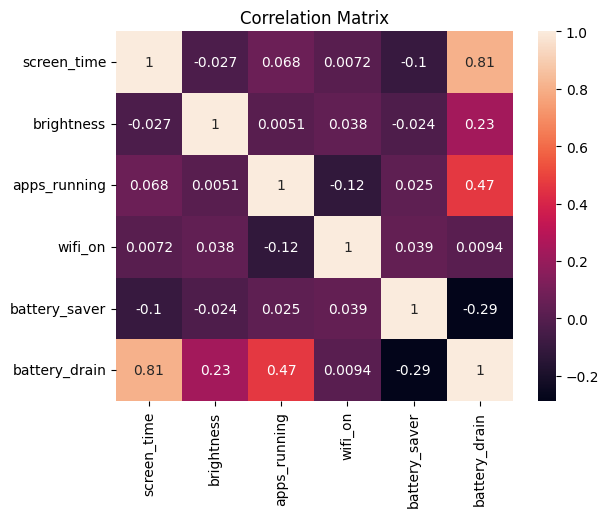

In [9]:
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

# 🔹 <font color="darkblue">**Scatter Plot :**

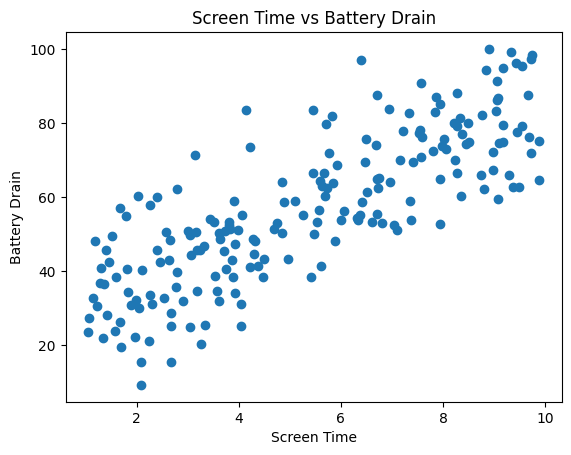

In [10]:
plt.scatter(df["screen_time"], df["battery_drain"])
plt.xlabel("Screen Time")
plt.ylabel("Battery Drain")
plt.title("Screen Time vs Battery Drain")
plt.show()

# **🔹<font color="darkblue">Distribution :**

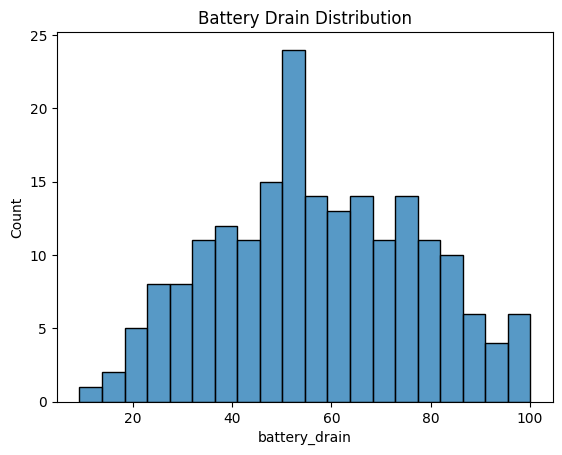

In [11]:
sns.histplot(df["battery_drain"], bins=20)
plt.title("Battery Drain Distribution")
plt.show()

# **🔹<font color="darkblue">Preparing Data: 🥣**

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop("battery_drain", axis=1)
y = df["battery_drain"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **🔹<font color="darkblue">Applying the 2 Algorithms: 👩🏻‍🍳🥣**

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

lr = LinearRegression()
dt = DecisionTreeRegressor()

**<font color="darkblue">Training ...........**

In [14]:
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)

DecisionTreeRegressor()

 **<font color="darkblue">Predictions ........**

In [15]:
y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)

#  **🔹<font color="darkblue">Evaluation : 📋✍️**

In [16]:
from sklearn.metrics import mean_absolute_error, r2_score

print("Linear Regression:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))

print("\nDecision Tree:")
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("R2:", r2_score(y_test, y_pred_dt))

Linear Regression:
MAE: 5.377757503545842
R2: 0.8859824825791962

Decision Tree:
MAE: 7.772880694270354
R2: 0.7309867469667579


### <font color="darkblue">**Coeffecients: (Linear Regression)🚀**

In [17]:
print(pd.Series(lr.coef_, index=X.columns))

screen_time      5.760406
brightness       0.201778
apps_running     1.592243
wifi_on          1.855364
battery_saver   -9.394793
dtype: float64


### **<font color="darkblue">Feature Importance: (Decision Tree)🌳𖣂**

In [18]:
importance = pd.Series(dt.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

screen_time      0.756770
apps_running     0.136126
brightness       0.068283
battery_saver    0.030808
wifi_on          0.008014
dtype: float64


# **🔹<font color="darkblue">Actual vs Predicted: (Graphing)**

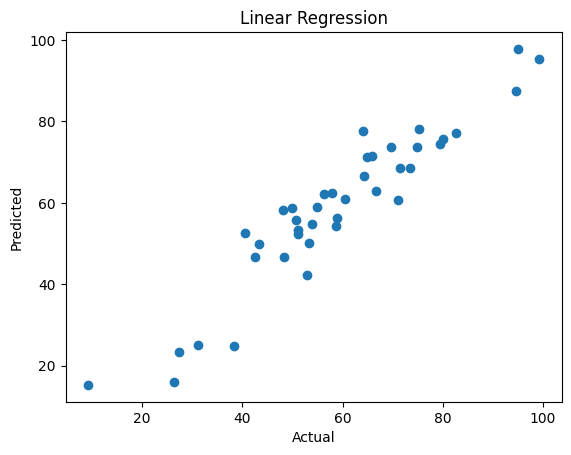

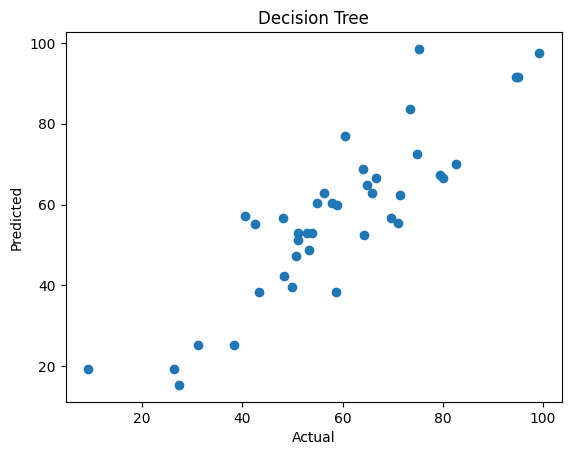

In [19]:
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression")
plt.show()

plt.scatter(y_test, y_pred_dt)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Decision Tree")
plt.show()

# **🔹<font color="darkblue">Conclusion : 📌**

### <center>*This project predicts mobile battery drain using features like screen time, brightness, app usage, WiFi usage, and battery saver mode.*

### <center>*A synthetic dataset was created with realistic relationships and noise. Battery saver showed a negative impact on drain, improving dataset realism. Linear Regression and Decision Tree were applied and compared. Linear Regression performed well due to the mostly linear relationships, while Decision Tree captured patterns differently but may overfit.*